# L96 figures and animations

In [ ]:
%load_ext autoreload
%autoreload 2

from L96 import *
import matplotlib.pyplot as plt
import numpy as np
from parameterizations import *
import torch
import torch.nn as nn
import torch.utils.data as Data
import os
from util import *
import re
import pickle
import datetime
import xarray as xr

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Load initial conditions for L96 model_autoencoder_autoencoder
initX, initY = np.load('./initX.npy'), np.load('./initY.npy')
np.random.seed(123)

In [8]:
L96 = xr.open_dataset('online_runs/NN+AE+D/input_lagg=1000/time=1000MTU_m=0.001_tau=0.001.nc', engine='netcdf4')
L96

<xarray.Dataset> Size: 648MB
Dimensions:      (time: 1000000, x: 8, latent_dims: 8, y: 256)
Coordinates:
  * time         (time) float64 8MB 0.0 0.001 0.002 0.003 ... 1e+03 1e+03 1e+03
  * x            (x) int64 64B 0 1 2 3 4 5 6 7
  * latent_dims  (latent_dims) int64 64B 0 1 2 3 4 5 6 7
  * y            (y) int64 2kB 0 1 2 3 4 5 6 7 ... 249 250 251 252 253 254 255
Data variables:
    X            (time, x) float64 64MB ...
    B            (time, x) float64 64MB ...
    Z            (time, x, latent_dims) float64 512MB ...
Attributes:
    m:               0.001
    tau:             0.001
    model:           NN+AE+D
    past_timesteps:  1000
    model_path:      networks/NN+AE+D/input_lagg=1000/m=0.001_tau=0.001_NN+AE...
    latent_dims:     8

# L96 model with memory

# Online Evaluation

In [ ]:
path = 'networks/NN+AE/input_lagg=1000/m=0.1_tau=0.0027825594022071257_NN+AE.pkl'
#path = 'networks/baseline_nn/input_lagg=0/m=0.1_tau=0.001_baseline_nn.pkl'

past_timesteps = int(re.search(r'input_lagg=(\d+)', path).group(1))
m = float(re.search(r'm=([\d.]+)', path).group(1))
tau = float(re.search(r'tau=([\d.]+)', path).group(1))
model = torch.load(path, weights_only=False, map_location=device)

L96 = L96TwoLevelMemory(X_init=None, Y_init=None, save_dt=.001, memory_cutoff=m, memory_tau=tau, memory_activation_func=None, parametrization=None)
L96.iterate(50)
X_train, X_test, B_train, B_test = generate_data(L96, past_timesteps, train_share=.01)
plot_predictions_vs_data(X_test, B_test, model, L96)

In [48]:
# Make completely new data
path = 'networks/nn/input_lagg=1000/m=0.1_tau=0.0027825594022071257_nn.pkl'
#path = 'networks/NN+AE/input_lagg=1000/m=0.1_tau=0.0027825594022071257_NN+AE.pkl'
#path = 'networks/baseline_nn/input_lagg=0/m=0.1_tau=0.0027825594022071257_baseline_nn.pkl'

past_timesteps = int(re.search(r'input_lagg=(\d+)', path).group(1))
m = float(re.search(r'm=([\d.]+)', path).group(1))
tau = float(re.search(r'tau=([\d.]+)', path).group(1))
model = torch.load(path, weights_only=False, map_location=device)

L96 = L96TwoLevelMemory(X_init=initX, Y_init=initY, save_dt=.001, memory_cutoff=m, memory_tau=tau, memory_activation_func=None, parametrization=model)
L96.iterate(50)
save_L96(L96)

Memory steps: 100


  0%|          | 0/50000 [00:00<?, ?it/s]

100%|██████████| 50000/50000 [00:42<00:00, 1166.89it/s]


In [ ]:
X_train, X_test, B_train, B_test = generate_data(L96, past_timesteps, train_share=.01)
plot_predictions_vs_data(X_test, B_test, model, L96)

Text(0, 0.5, 'B')

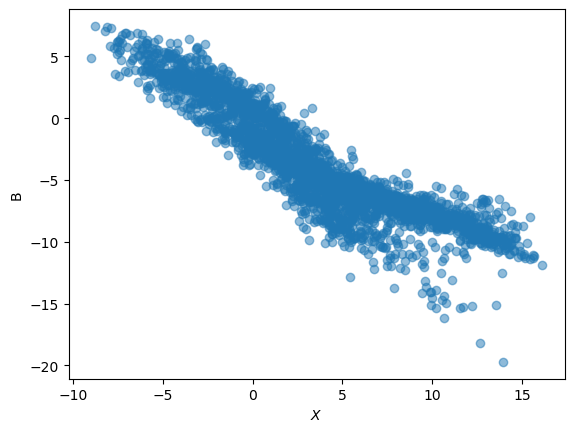

In [5]:
path = 'online_runs/nn/input_lagg=1000/time=200000_m=0.001_tau=0.001.pkl'
with open(path, 'rb') as file:
        L96_pkl = pickle.load(file)
plt.scatter(L96_pkl.history.X.values.flatten()[::100], L96_pkl.history.B.values.flatten()[::100], alpha=.5, label='NN, past_t = 1000')
plt.xlabel(r'$X$')
plt.ylabel(r'B')

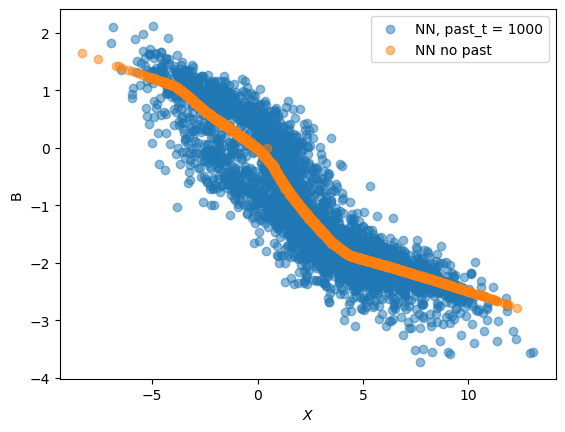

In [6]:
#path = 'online_runs/baseline_nn/input_lagg=0/time=50000_m=0.1_tau=0.0027825594022071257.pkl'
#path = 'online_runs/NN+AE/input_lagg=1000/time=50000_m=0.1_tau=0.0027825594022071257.pkl'
path = 'online_runs/nn/input_lagg=1000/time=50000_m=0.1_tau=0.0027825594022071257.pkl'
with open(path, 'rb') as file:
        L96_pkl = pickle.load(file)
plt.scatter(L96_pkl.history.X.values.flatten()[::500], L96_pkl.history.B.values.flatten()[::500], alpha=.5, label='NN, past_t = 1000')
plt.xlabel(r'$X$')
plt.ylabel(r'B')

path = 'online_runs/baseline_nn/input_lagg=0/time=50000_m=0.1_tau=0.0027825594022071257.pkl'
#path = 'online_runs/NN+AE/input_lagg=1000/time=50000_m=0.1_tau=0.0027825594022071257.pkl'
with open(path, 'rb') as file:
        L96_pkl = pickle.load(file)
plt.scatter(L96_pkl.history.X.values.flatten()[::500], L96_pkl.history.B.values.flatten()[::500], alpha=.5, label='NN no past')
plt.xlabel(r'$X$')
plt.ylabel(r'B')

plt.legend()

# Compare different "Climates"

In [20]:
def L96_from_nc(path):
    XB = xr.load_dataset(path)
    L96 = L962LvlMem()
    L96._history_X = XB.X
    L96._history_B = XB.B

    return L96

In [22]:
path = 'online_runs/baseline_nn/input_lagg=0/time=1000000_m=0.001_tau=0.001.pkl'
path = 'online_runs/baseline_nn/input_lagg=0/time=10000MTU_m=0.001_tau=0.001.nc'
L96_base0 = L96_from_nc(path)
# with open(path, 'rb') as file:
#         L96_base0 = pickle.load(file)

#path = 'online_runs/baseline_nn/input_lagg=0/time=1000000_m=0.001_tau=0.001.pkl'
path = 'online_runs/NN/input_lagg=0/time=10000MTU_m=0.001_tau=0.001.pkl'
with open(path, 'rb') as file:
        L96_base = pickle.load(file)

#path = 'online_runs/NN+AE_latent_dims=1/input_lagg=1000/time=1000000_m=0.001_tau=0.001.pkl'
# path = 'online_runs/NN+AE/input_lagg=1000/time=10000MTU_m=0.001_tau=0.001.pkl'
# with open(path, 'rb') as file:
#         L96_ae18 = pickle.load(file)

#path = 'online_runs/NN+AE_latent_dims=1/input_lagg=1000/time=1000000_m=0.001_tau=0.001.pkl'
path = 'online_runs/NN+AE_latent_dims=1/input_lagg=1000/time=10000MTU_m=0.001_tau=0.001.nc'
L96_ae11 = L96_from_nc(path)
# with open(path, 'rb') as file:
#         L96_ae11 = pickle.load(file)

# path = 'online_runs/nn/input_lagg=1000/time=1000000_m=0.001_tau=0.001.pkl'
# with open(path, 'rb') as file:
#         L96_nn = pickle.load(file)

# path = 'online_runs/NN+AE_latent_dims=5/input_lagg=1000/time=1000000_m=0.001_tau=0.001.pkl'
# with open(path, 'rb') as file:
#         L96_ae5 = pickle.load(file)

path = 'online_runs/NO_PARAMETRIZATION/time=10000000_m=0.001_tau=0.001.pkl'
with open(path, 'rb') as file:
        L96_true = pickle.load(file)

Memory steps: 1
Memory steps: 1


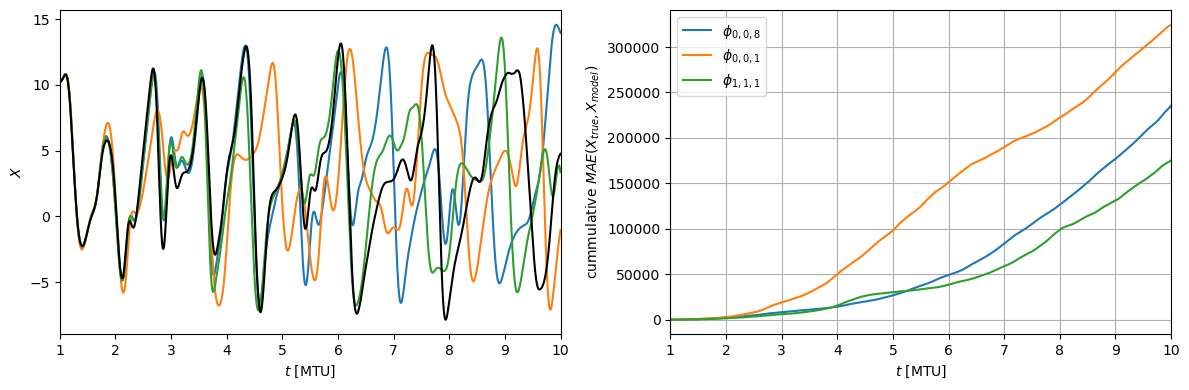

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
tmax = 10_000
X_true = L96_true.history.X.values[:tmax]
t = np.arange(0, len(X_true)  ) *L96_true.dt 
k = 2

for L96, model_name in zip([L96_base, L96_base0, L96_ae11], [r'$\phi_{0,0,8}$', r'$\phi_{0,0,1}$', r'$\phi_{1,1,1}$']):
    X = L96.history.X.values[:tmax]
    MAE = np.cumsum(np.sum(np.absolute(X_true-X), axis=1))
    axs[1].plot(t, MAE, label=model_name)
    axs[0].plot(t, X[:, k], label=model_name)

#X_true = L96_true.history.X.values[:tmax, k]
axs[0].plot(t, X_true[:, k], label='true', color='black')

axs[1].legend()
axs[1].set(xlabel=r'$t$ [MTU]', ylabel=r'$MAE(X_{true}, X_{model})$', xlim=(1, 10))
axs[0].set(xlabel=r'$t$ [MTU]', ylabel=r'$X$', xlim=(1, 10))
plt.xlabel(r'$t$ [MTU]')
plt.ylabel(r'cummulative $MAE(X_{true}, X_{model})$')
plt.grid()
plt.tight_layout()

In [24]:
def H(p, q):
  # distance between p an d
  # p and q are np array probability distributions
  n = len(p)
  sum = 0.0
  for i in range(n):
    sum += (np.sqrt(p[i]) - np.sqrt(q[i]))**2
  result = (1.0 / np.sqrt(2.0)) * np.sqrt(sum)
  return result

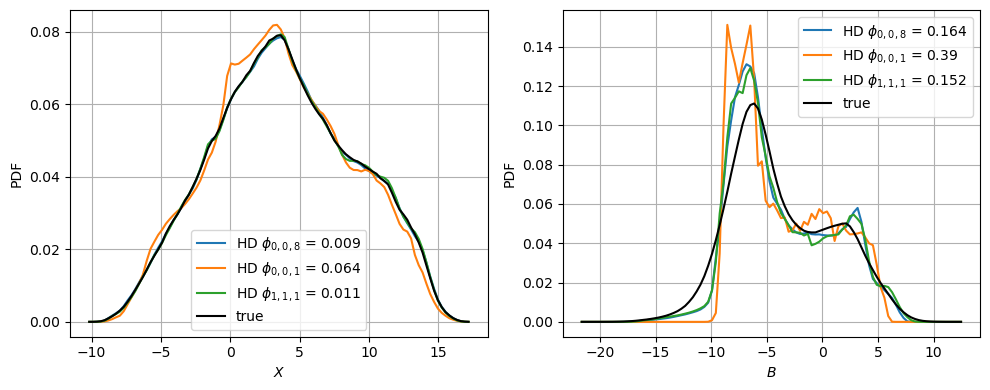

In [25]:
B_true = L96_true.history.B.values.flatten()
X_true = L96_true.history.X.values.flatten()
P_X_true, Xbins = np.histogram(X_true, bins=100, density=True)
P_B_true, Bbins = np.histogram(B_true, bins=100, density=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.set(xlabel=r'$X$', ylabel='PDF')
ax2.set(xlabel=r'$B$', ylabel='PDF')

for L96, model_name in zip([L96_base, L96_base0, L96_ae11], [r'$\phi_{0,0,8}$', r'$\phi_{0,0,1}$', r'$\phi_{1,1,1}$']):
    B = L96.history.B.values.flatten()
    X = L96.history.X.values.flatten()

    P_X, _ = np.histogram(X, bins=Xbins, density=True)
    P_B, _ = np.histogram(B, bins=Bbins, density=True)

    ax1.plot(Xbins[1:], P_X, label=f'HD {model_name} = {round(H(P_X_true, P_X), 3)}')
    ax2.plot(Bbins[1:], P_B, label=f'HD {model_name} = {round(H(P_B_true, P_B), 3)}')

ax1.plot(Xbins[1:], P_X_true, label=f'true', c='black')
ax2.plot(Bbins[1:], P_B_true, label=f'true', c='black')

for ax in [ax1, ax2]:
    ax.legend()
    ax.grid()

plt.tight_layout()

# Parametrization of $B$ 

[0.83989358 0.83667278 0.8298198  0.82599336 0.80909568 0.77126145
 0.64675999 0.39626199 0.12764168 0.06219363]
[0.93075764 0.9267149  0.93924069 0.93518043 0.93557727 0.9361037
 0.93269205 0.93767095 0.94068331 0.90903306]
[0.93728817 0.93001568 0.94240129 0.93812895 0.93941343 0.93742925
 0.93880802 0.94133729 0.94424188 0.9151004 ]
[0.93546903 0.92964733 0.93862683 0.93591106 0.93725848 0.93663156
 0.93337047 0.93849164 0.94164866 0.91140431]


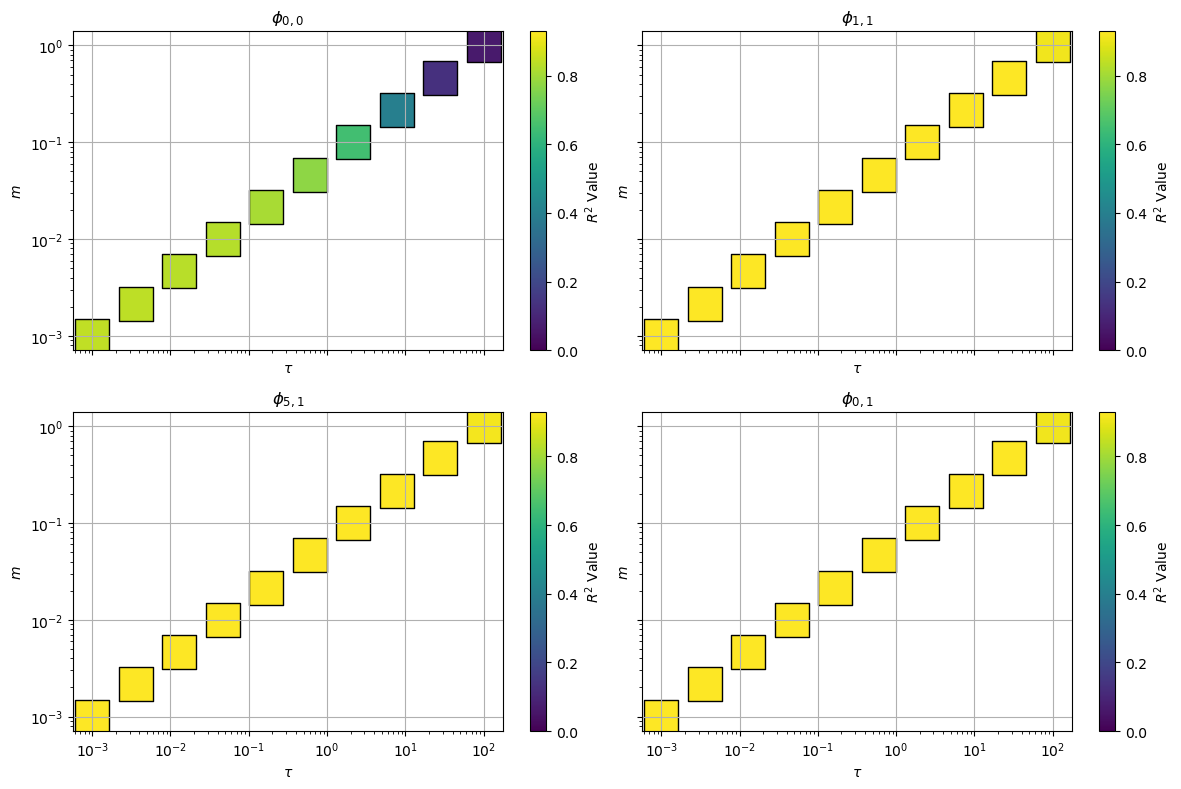

In [16]:
fig , axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for mname, pt, title, ax in zip(['baseline_nn', 'NN+AE_latent_dims=1', 'NN+AE_latent_dims=5', 'nn'], [0, 1000, 1000, 1000], [r'$\phi_{0,0}$', r'$\phi_{1,1}$', r'$\phi_{5,1}$', r'$\phi_{0,1}$'], axs.flatten()):
    memory_sensitivity(mname, past_timesteps=pt, fig=fig, ax=ax, vmin=0, vmax=.93)
    ax.title.set_text(title)
plt.tight_layout()

Text(0.5, 1.0, '$\\phi_{1,1}$ - $\\phi_{0,1}$')

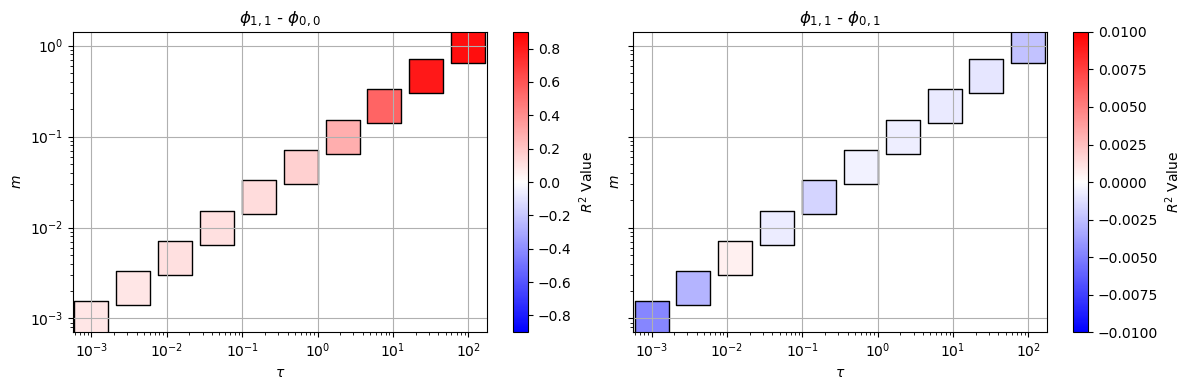

In [54]:
# Sensitivity to memory parameters
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
memory_sensitivity('NN+AE_latent_dims=1', past_timesteps=1000, minus=['baseline_nn', 0], cmap='bwr', vmin=-.9, vmax=.9, fig=fig, ax=axs[0])
axs[0].set_title(r'$\phi_{1,1}$ - $\phi_{0,0}$')
memory_sensitivity('NN+AE_latent_dims=1', past_timesteps=1000, minus=['nn', 1000], cmap='bwr', vmin=-.01, vmax=.01, fig=fig, ax=axs[1])
axs[1].set_title(r'$\phi_{1,1}$ - $\phi_{0,1}$')

[0.93075764 0.9267149  0.93924069 0.93518043 0.93557727 0.9361037
 0.93269205 0.93767095 0.94068331 0.90903306]


Text(0.5, 1.0, '$\\phi_{1,1,1}$')

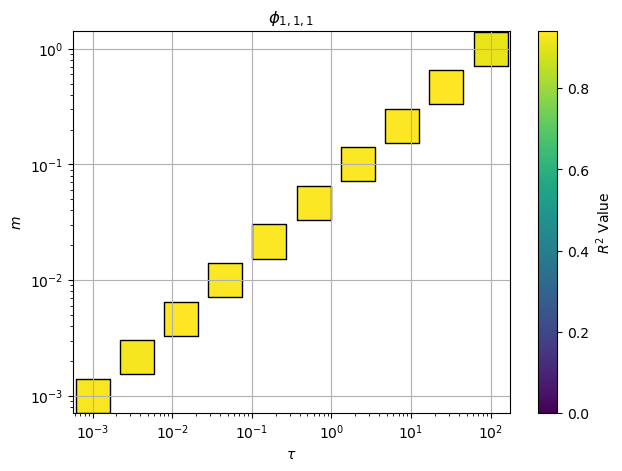

In [11]:
memory_sensitivity('NN+AE_latent_dims=1', past_timesteps=1000, minus=None, vmax=.94)
plt.title(r'$\phi_{1,1,1}$')

[0.92211074 0.91825151 0.92507601 0.91933519 0.91850984 0.91791016
 0.90784645 0.86788082 0.69852459 0.36408621]


Text(0.5, 1.0, '$\\phi_{0,0,8}$')

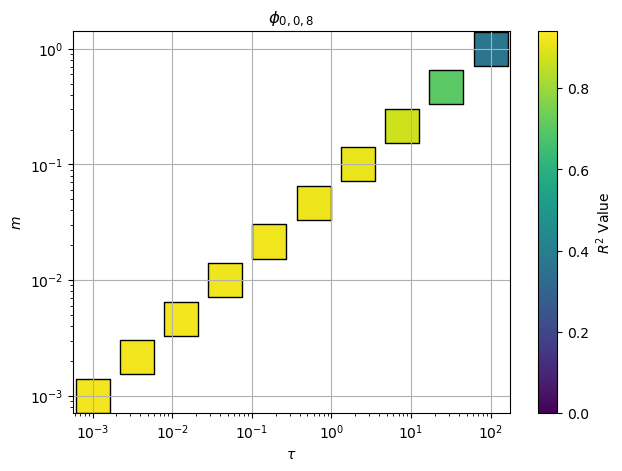

In [10]:
memory_sensitivity('NN', past_timesteps=0, minus=None, vmax=.94)
plt.title(r'$\phi_{0,0,8}$')

[0.83989358 0.83667278 0.8298198  0.82599336 0.80909568 0.77126145
 0.64675999 0.39626199 0.12764168 0.06219363]


Text(0.5, 1.0, '$\\phi_{0,0,1}$')

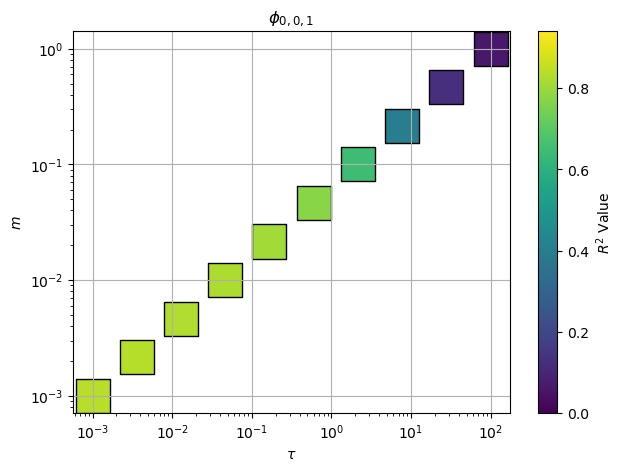

In [13]:
memory_sensitivity('baseline_nn', past_timesteps=0, minus=None, vmax=.94)
plt.title(r'$\phi_{0,0,1}$')

[0.93546903 0.92964733 0.93862683 0.93591106 0.93725848 0.93663156
 0.93337047 0.93849164 0.94164866 0.91140431]


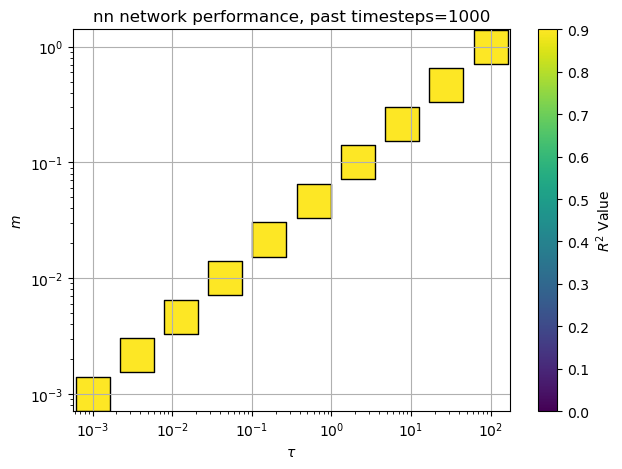

In [118]:
memory_sensitivity('nn', past_timesteps=1000, minus=None)

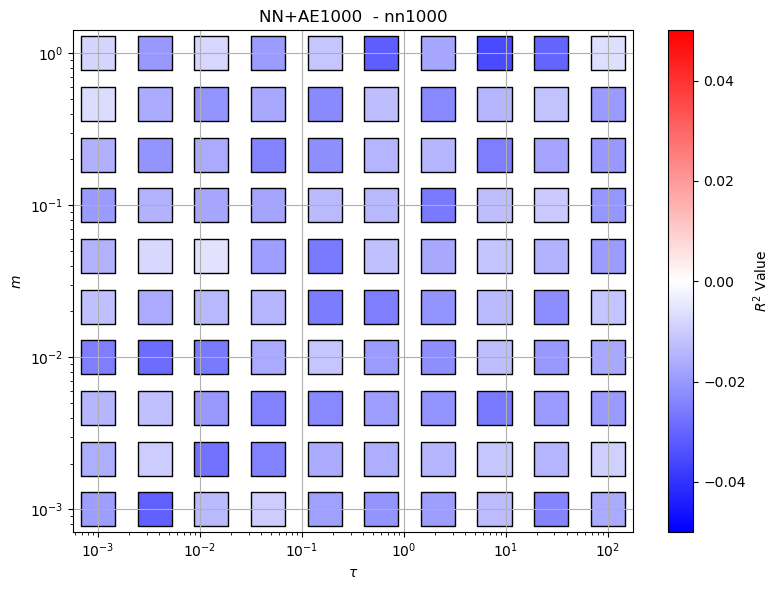

In [17]:
memory_sensitivity('NN+AE', past_timesteps=1000, minus=['nn', 1000], vmin=-.05, vmax=.05, cmap='bwr')

# Compressed Memory

In [ ]:
past_timesteps = 1000

# Data
print('preprocessing')
dataloader_train, dataloader_test, X_train, X_test, B_train, B_test = generate_data(L96, past_timesteps=past_timesteps, BATCH_SIZE=1_000)
print('train')
# Model
nn_memory_model = FCNN(past_timesteps=past_timesteps, nodes_per_layer=50)

# Training
nn_memory_model = train_model(dataloader_train, dataloader_test, nn_memory_model)
#nn_memory_model = train_model(X_train, B_train, X_test, B_test, nn_memory_model, num_epochs=100)


In [12]:
import sys
a = X_train
a.element_size() * a.nelement()

11416204800

In [8]:
# Model
nn_memory_model = FCNN(past_timesteps=past_timesteps, nodes_per_layer=50)

# Training
#nn_memory_model = train_model(dataloader_train, dataloader_test, nn_memory_model)
nn_memory_model = train_model(X_train, B_train, X_test, B_test, nn_memory_model, num_epochs=200)

xT: cuda:0, bT: cuda:0, model params: cuda:0
Epoch:1, train loss 2.5146, test loss 2.1808, test R2 -0.40
xT: cuda:0, bT: cuda:0, model params: cuda:0
Epoch:2, train loss 2.1808, test loss 1.7914, test R2 -0.15
xT: cuda:0, bT: cuda:0, model params: cuda:0
Epoch:3, train loss 1.7914, test loss 1.4722, test R2 0.06
xT: cuda:0, bT: cuda:0, model params: cuda:0
Epoch:4, train loss 1.4722, test loss 1.2292, test R2 0.21
xT: cuda:0, bT: cuda:0, model params: cuda:0
Epoch:5, train loss 1.2292, test loss 1.0322, test R2 0.34
xT: cuda:0, bT: cuda:0, model params: cuda:0
Epoch:6, train loss 1.0322, test loss 0.8524, test R2 0.45
xT: cuda:0, bT: cuda:0, model params: cuda:0
Epoch:7, train loss 0.8524, test loss 0.7198, test R2 0.54
xT: cuda:0, bT: cuda:0, model params: cuda:0
Epoch:8, train loss 0.7198, test loss 0.6790, test R2 0.57
xT: cuda:0, bT: cuda:0, model params: cuda:0
Epoch:9, train loss 0.6790, test loss 0.6890, test R2 0.56
xT: cuda:0, bT: cuda:0, model params: cuda:0
Epoch:10, train l

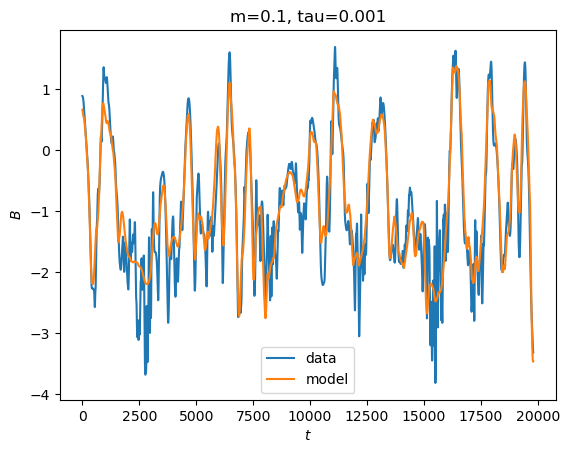

In [9]:
plot_predictions_vs_data(X_test, B_test, nn_memory_model, L96)

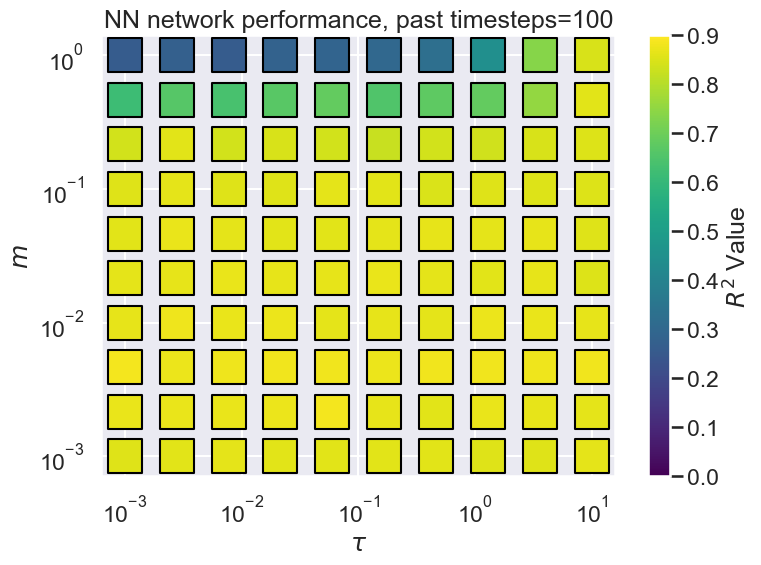

In [31]:
# Sensitivity to memory parameters
memory_sensitivity('nn', past_timesteps=100)

# Parametrization with Autoencoder

In [109]:
past_timesteps, latent_dims = 1000, 5

# Load data for Autoencoder
dataloader_train, dataloader_test, X_train, X_test = generate_data_autoencoder(L96, past_timesteps)

# Train Autoencoder
print('train autoencoder')
autoencoder_model = Autoencoder(past_timesteps=past_timesteps, latent_dims=latent_dims)
autoencoder_model = train_model(dataloader_train, dataloader_test, autoencoder_model)

# Load data for NN+Autoencoder
dataloader_train, dataloader_test, ZX_test, B_test = generate_data_nn_autoencoder(L96, past_timesteps, autoencoder_model)

# Train NN
print('train nn')
nn_autoencoder_model = FCNN(past_timesteps=latent_dims, nodes_per_layer=16)
nn_autoencoder_model = train_model(dataloader_train, dataloader_test, nn_autoencoder_model)

train autoencoder
Epoch:1, train loss 5.2580, test loss 1.5277, test R2 0.88
Epoch:2, train loss 1.0591, test loss 1.1237, test R2 0.91
Epoch:3, train loss 0.6342, test loss 0.6330, test R2 0.95
Epoch:4, train loss 0.4364, test loss 0.5420, test R2 0.96
Epoch:5, train loss 0.4016, test loss 0.5165, test R2 0.96
train nn
Epoch:1, train loss 0.6417, test loss 0.4759, test R2 0.69
Epoch:2, train loss 0.3429, test loss 0.3710, test R2 0.76
Epoch:3, train loss 0.2948, test loss 0.3434, test R2 0.78
Epoch:4, train loss 0.2771, test loss 0.3299, test R2 0.79
Epoch:5, train loss 0.2665, test loss 0.3189, test R2 0.79


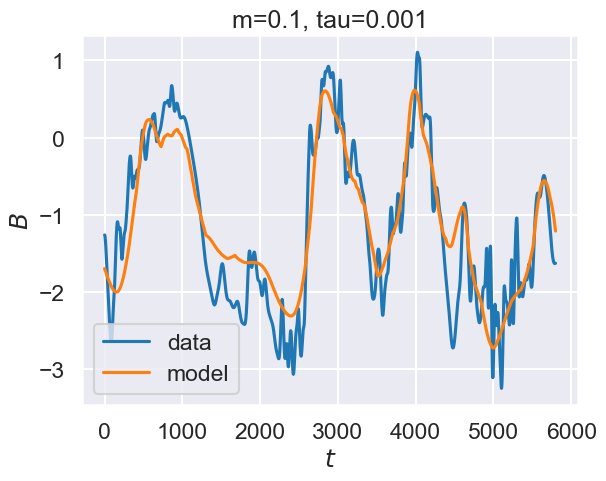

In [110]:
plot_predictions_vs_data(ZX_test, B_test, nn_autoencoder_model, L96)

In [21]:
# Check if number of parameters are comparable for two different models
def nparams(models):
    np = 0
    for model in models:
        np+=sum(p.numel() for p in model.parameters() if p.requires_grad)
    return np

pt = 1000
print(nparams([FCNN(pt, 50)]))
print(nparams([NNpAE(past_timesteps=1000, latent_dims=5, nodes_per_layer=50)]))

57801
43430


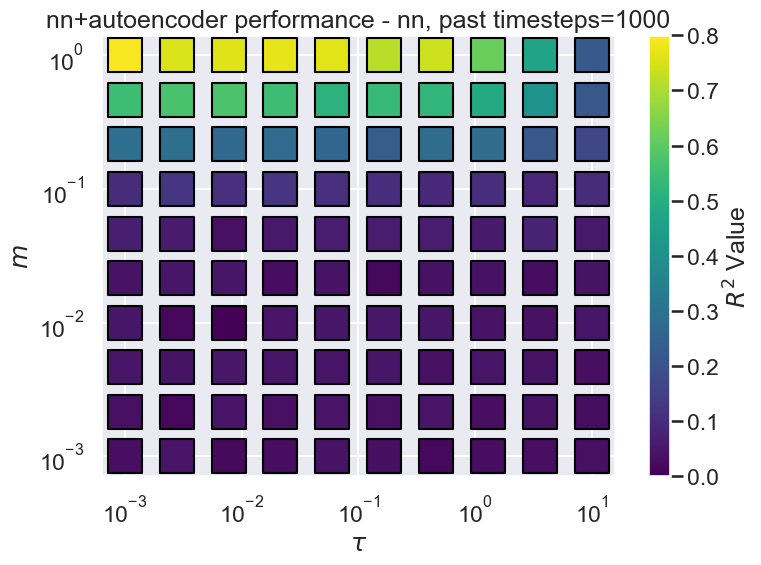

In [99]:
memory_sensitivity('nn+autoencoder', 1000, minus=['nn', 0], vmax=.8)

In [2]:
with open('online_runs/NO_PARAMETRIZATION/time=10000000_m=0.001_tau=0.001.pkl', 'rb') as file:
    L96 = pickle.load(file)

In [3]:
Nt = 1000 * 1000
past_timesteps = 1000
model811 = NNpAE(past_timesteps, 8)
m, tau = .001, .001
L96_subset = L962LvlMem(m=m, tau=tau)
L96_subset._history_X = L96._history_X[:Nt]
L96_subset._history_B = L96._history_B[:Nt]
print(m, tau, L96.m, L96.tau)
L96 = L96_subset
X_train, X_test, B_train, B_test = generate_data(L96, past_timesteps)

Memory steps: 1
0.001 0.001 0.001 0.001


In [ ]:
train_model(X_train, X_test, B_train, B_test, model811, num_epochs=2_000);

Training: 100%|████████████████████████████| 2000/2000 [04:43<00:00,  7.06it/s, Train Loss=1.3447, Test Loss=1.3233, R²=0.9369, Best R²=0.9388 @ 1956]


NNpAE(
  (encoder): Sequential(
    (0): Linear(in_features=1000, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=12, bias=True)
    (5): ReLU()
    (6): Linear(in_features=12, out_features=8, bias=True)
  )
  (neural_net): Sequential(
    (0): Linear(in_features=9, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [5]:
model = set_model_metadata(model811, past_timesteps, 8, model_name='NN+AE', m=m, tau=tau)
save_model(model)

# Add non-local variables to AE

In [3]:
# L96 = L962LvlMem(m=.001, tau=.001)
# L96.iterate(1000)

In [4]:
def load_data(dim):
    X = np.load(f'/work/bd1179/b309297/L96/latent_space_data/dim={dim}_t=5000MTU_pt=1000_m=0.001_tau=0.001/X.npy').reshape(-1, 8, 1)
    B = np.load(f'/work/bd1179/b309297/L96/latent_space_data/dim={dim}_t=5000MTU_pt=1000_m=0.001_tau=0.001/B.npy').reshape(-1, 8)
    Z = np.load(f'/work/bd1179/b309297/L96/latent_space_data/dim={dim}_t=5000MTU_pt=1000_m=0.001_tau=0.001/Z.npy').reshape(-1, 8, dim)
    T = np.arange(B.shape[0]) * 0.001
    return X, B, Z, T

dim = 3
X, B, Z, T = load_data(dim)
discover_MTUs = 1000 * 1000
X = X[:discover_MTUs][:,:,0]
B = B[:discover_MTUs]
# Z = Z[:discover_MTUs]
T = T[:discover_MTUs]

# X = L96.history.X.values
# B = L96.history.B.values

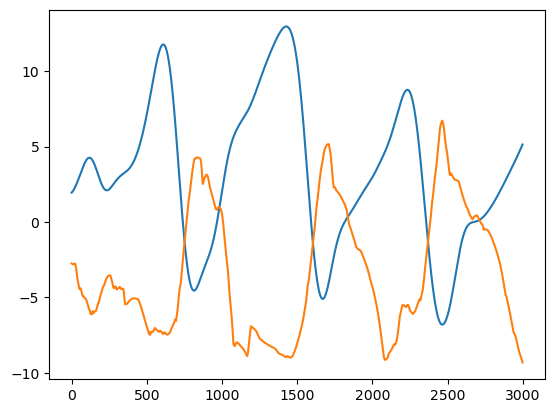

In [17]:
with open('online_runs/NN/input_lagg=0/time=1000MTU_m=0.001_tau=0.001.pkl', 'rb') as file:
    L96 = pickle.load(file)

X = L96.history.X.values
B = L96.history.B.values
#Z = L96.history.Z.values

plt.plot(X[2000:5000, 1])
plt.plot(B[2000:5000, 1])
#plt.plot(Z[2000:5000, 1, 0])

In [ ]:
class NN(nn.Module):
    def __init__(self,past_timesteps, n_neighbours, nodes_per_layer=16):
        super().__init__()
        self.past_timesteps = past_timesteps
        self.n_neighbours = n_neighbours
        self.nodes_per_layer = nodes_per_layer

        self.neural_net = nn.Sequential(
            nn.Linear(self.past_timesteps + self.n_neighbours, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, 1)
        )

        # Loss
        self.train_loss = []
        self.test_loss = []

        # R^2
        self.R2 = []

        # Metadata
        self.memory_cutoff = None
        self.tau = None
        self.model_name = 'NN'
        self.latent_dims = 0

    def forward(self, x):
        y_pred = self.neural_net(x)
        return y_pred
    
class NNpAE(nn.Module):
    def __init__(self, past_timesteps, n_neighbours, latent_dims, nodes_per_layer=16):
        super().__init__()

        self.past_timesteps = past_timesteps
        self.n_neighbours = n_neighbours
        self.latent_dims = latent_dims
        self.nodes_per_layer = nodes_per_layer

        self.encoder = nn.Sequential(
            nn.Linear(self.past_timesteps, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 12),
            nn.ReLU(),
            nn.Linear(12, self.latent_dims)
        )

        self.neural_net = nn.Sequential(
            nn.Linear(latent_dims + n_neighbours, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, 1)
        )

        # Loss
        self.train_loss = []
        self.test_loss = []

        # R^2
        self.R2 = []

        # Metadata
        self.memory_cutoff = None
        self.tau = None
        self.model_name = 'NN+AE'

    def forward(self, x):
        x_past = x[:, :self.past_timesteps]
        x_present = x[:, self.past_timesteps:]

        latent_space = self.encoder(x_past)
        x_nn = torch.cat((latent_space, x_present), dim=1)

        y_pred = self.neural_net(x_nn)
        
        return y_pred


def train_model_NN(x, x_test, dZdt, dZdt_test, model, num_epochs=5):
    # Send to gpu if available
    model = model.to(device)
    criterion = nn.MSELoss()
    lr = .007
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Make progress bar
    best_R2 = float('-inf')
    best_R2_epoch = 0
    pbar = trange(num_epochs, desc="Training", ncols=150)

    # Training
    for epoch in pbar:
        model.train()
        test_loss, train_loss, R2 = 0, 0, 0

        # Transpose 1-dimensional data
        dZdt_pred = model.forward(x)
        loss = criterion(dZdt_pred, dZdt)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
        model.eval()
        with torch.no_grad():
            # Transpose 1-dimensional data
            dZdt_pred = model.forward(x_test)
            loss = criterion(dZdt_pred, dZdt_test)
            R2 += R2Score().to(device)(dZdt_pred, dZdt_test)
            test_loss += loss.item()
        
        train_loss = train_loss 
        test_loss = test_loss 
        model.train_loss.append(train_loss)
        model.test_loss.append(test_loss)
        model.R2.append(R2)

        # Update best R²
        if R2 > best_R2:
            best_R2 = R2
            best_R2_epoch = epoch + 1

        # Inline update
        pbar.set_postfix({
            "Train Loss": f"{train_loss:.4f}",
            "Test Loss": f"{test_loss:.4f}",
            "R²": f"{R2:.4f}",
            "Best R²": f"{best_R2:.4f} @ {best_R2_epoch}"})
    
    return model

In [42]:
#path = 'networks/phi_0_1.0_8_m=None_tau=None_20250717114600.pkl'
path = 'networks/phi_0_0.0_8_m=None_tau=None_20250717112413.pkl'
#path = 'networks/phi_1_1.0_8_m=0.001_tau=0.001_20250717104927.pkl'
model = torch.load(path, weights_only=False)

In [6]:
def train_test_split(arr, Ntrain):
    return arr[:Ntrain], arr[Ntrain:]

In [ ]:
Ntrain = int(X.shape[0] * .8)
def train_test_split(arr, Ntrain):
    return arr[:Ntrain], arr[Ntrain:]

X_train, X_test = train_test_split(X, Ntrain)
B_train, B_test = train_test_split(B, Ntrain)

past_timesteps = 1000

X_train = torch.tensor(return_lagged_input_vector_and_present_k(X_train.T, past_timesteps), dtype=torch.float32, device=device)
X_test = torch.tensor(return_lagged_input_vector_and_present_k(X_test.T, past_timesteps), dtype=torch.float32, device=device)
B_train = torch.tensor(B_train[past_timesteps:].T.flatten().reshape(-1, 1), dtype=torch.float32, device=device)
B_test = torch.tensor(B_test[past_timesteps:].T.flatten().reshape(-1, 1), dtype=torch.float32, device=device)

print(X_train.shape, B_train.shape)
print(past_timesteps)
model = NNpAE(past_timesteps, n_neighbours=8, latent_dims=1)
model.tau = 0.001
model.memory_cutoff = 0.001
model = train_model(X_train, X_test, B_train, B_test, model, num_epochs=10_000)
save_model(model)

torch.Size([6384000, 2008]) torch.Size([6384000, 1])
2000


Training: 100%|██████████████████████████| 10000/10000 [30:21<00:00,  5.49it/s, Train Loss=1.2899, Test Loss=1.3350, R²=0.9364, Best R²=0.9371 @ 9759]


In [ ]:
print(past_timesteps)
model = NNpAE(past_timesteps, n_neighbours=8, latent_dims=1)
model.tau = 0.001
model.memory_cutoff = 0.001
model = train_model(X_train, X_test, B_train, B_test, model, num_epochs=10_000)


100


Training: 100%|███████████████████████████████| 300/300 [00:34<00:00,  8.65it/s, Train Loss=1.8221, Test Loss=1.8235, R²=0.9131, Best R²=0.9131 @ 300]


In [26]:
def save_model(model):
    exp_id = datetime.datetime.now().strftime('%Y%m%d%H%M%S')
    path = f'networks/phi_{model.latent_dims}_{model.past_timesteps/1000}_{model.n_neighbours}_m={model.memory_cutoff}_tau={model.tau}_{exp_id}.pkl'
    torch.save(model, path)

In [34]:
past_timesteps = 1000
X_train, X_test = train_test_split(X, Ntrain)
B_train, B_test = train_test_split(B, Ntrain)

X_train = torch.tensor(return_lagged_input_vector_and_present_k(X_train.T, past_timesteps), dtype=torch.float32, device=device)
X_test = torch.tensor(return_lagged_input_vector_and_present_k(X_test.T, past_timesteps), dtype=torch.float32, device=device)
B_train = torch.tensor(B_train[past_timesteps:].T.flatten().reshape(-1, 1), dtype=torch.float32, device=device)
B_test = torch.tensor(B_test[past_timesteps:].T.flatten().reshape(-1, 1), dtype=torch.float32, device=device)
print(past_timesteps)
model = NN(past_timesteps=past_timesteps, n_neighbours=8)
train_model(X_train, X_test, B_train, B_test, model, num_epochs=10_000)
save_model(model)

1000


Training: 100%|██████████████████████████| 10000/10000 [16:55<00:00,  9.85it/s, Train Loss=1.2619, Test Loss=1.2867, R²=0.9387, Best R²=0.9390 @ 9886]


In [113]:
model = NNpAE(past_timesteps, n_neighbours=8, latent_dims=1)
train_model(X_train, X_test, B_train, B_test, model, num_epochs=10_000)

Training: 100%|██████████████████████████| 10000/10000 [22:19<00:00,  7.47it/s, Train Loss=1.2713, Test Loss=1.2607, R²=0.9399, Best R²=0.9413 @ 9714]


NNpAE(
  (encoder): Sequential(
    (0): Linear(in_features=1000, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=12, bias=True)
    (5): ReLU()
    (6): Linear(in_features=12, out_features=1, bias=True)
  )
  (neural_net): Sequential(
    (0): Linear(in_features=9, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [109]:
model = NNpAE(past_timesteps, n_neighbours=8, latent_dims=3)
train_model(X_train, X_test, B_train, B_test, model, num_epochs=10_000)

Training:   0%|                                                                                                             | 0/10000 [00:00<?, ?it/s]

Training: 100%|██████████████████████████| 10000/10000 [23:16<00:00,  7.16it/s, Train Loss=1.2293, Test Loss=1.2660, R²=0.9397, Best R²=0.9410 @ 9913]


NNpAE(
  (encoder): Sequential(
    (0): Linear(in_features=1000, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=12, bias=True)
    (5): ReLU()
    (6): Linear(in_features=12, out_features=3, bias=True)
  )
  (neural_net): Sequential(
    (0): Linear(in_features=11, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [10]:
Ntrain = int(X.shape[0] * .8)
def train_test_split(arr, Ntrain):
    return arr[:Ntrain], arr[Ntrain:]

X_train, X_test = train_test_split(X, Ntrain)
B_train, B_test = train_test_split(B, Ntrain)

past_timesteps = 1000

X_train = torch.tensor(return_lagged_input_vector_opt(X_train.T, past_timesteps), dtype=torch.float32, device=device)
X_test = torch.tensor(return_lagged_input_vector_opt(X_test.T, past_timesteps), dtype=torch.float32, device=device)
B_train = torch.tensor(return_lagged_input_vector_opt(B_train.T, past_timesteps), dtype=torch.float32, device=device)[:,0].reshape(-1,1)
B_test = torch.tensor(return_lagged_input_vector_opt(B_test.T, past_timesteps), dtype=torch.float32, device=device)[:,0].reshape(-1,1)

print(X_train.shape, B_train.shape)

torch.Size([3192000, 1001]) torch.Size([3192000, 1])


In [ ]:
from parameterizations import *
torch.cuda.empty_cache()
import gc
gc.collect()

3258

In [14]:
X, B, model = None, None, None

In [15]:
#model = NNpAE(past_timesteps, latent_dims=3, n_neighbours=8, nodes_per_layer=16)
model = NNpAEpD(n_neighbours=1, past_timesteps=past_timesteps, latent_dims=8)
model = train_model_NNpAEpD(X_train, X_test, B_train, B_test, model, num_epochs=5000)

Training:   0%|                                                                                                              | 0/5000 [00:00<?, ?it/s]

Training: 100%|████████████████████████████| 5000/5000 [19:08<00:00,  4.35it/s, Train Loss=1.2299, Test Loss=1.2375, R²=0.8980, Best R²=0.8995 @ 4838]


In [16]:
save_model(model)

In [17]:
model = torch.load('networks/NN+AE+D/input_lagg=1000/m=None_tau=None_NN+AE+D.pkl', weights_only=False)

In [20]:
X_test.shape
b, x_recon = model.forward(X_test)

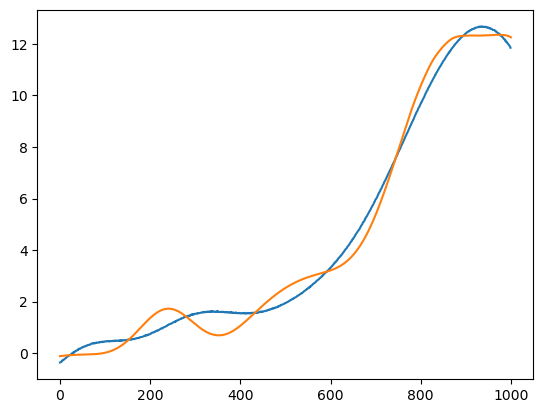

In [44]:
#b, x_recon = b.detach().cpu().numpy(), x_recon.detach().cpu().numpy()
#x_test = X_test.detach().cpu().numpy()
idx = 10294
plt.plot(x_recon[idx])
plt.plot(x_test[idx])

In [95]:
k = 2
ks = np.arange(k+1, k + 8)

ks % 8

array([3, 4, 5, 6, 7, 0, 1])

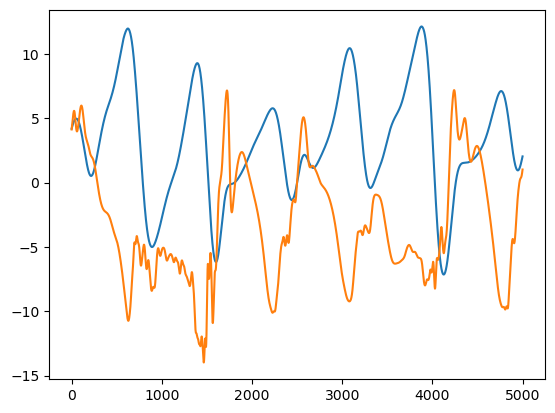

In [29]:
plt.plot(X[:5000, 7])
plt.plot(B[:5000, 0])

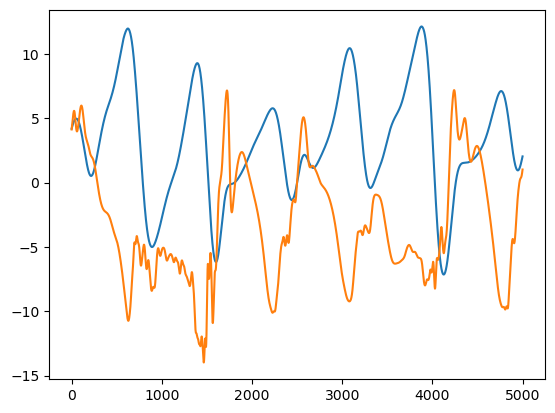

In [30]:
plt.plot(X_train[:5000, 7].cpu().numpy())
plt.plot(B_train[:5000, 0].cpu().numpy())

In [28]:
X_lagged.shape

(6399200, 108)

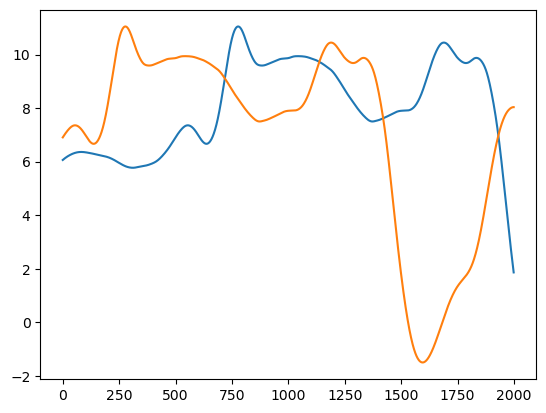

In [26]:
# plt.plot(Xks_lagged[:5000, 0, -1].cpu().numpy(), label='data')
# plt.plot(Xks_lagged[:5000, 0, 500].cpu().numpy(), label='lagged data')
# plt.legend()

plt.plot(X_lagged[:2000, 500])
plt.plot(X_lagged[:2000, 1000])
#plt.plot(X_lagged[:2000, 1001])

In [73]:
model = FCNN(past_timesteps=0)

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'memory cutoff=0.001, tau=0.001'}, xlabel='X (resolved variable)', ylabel='B (sub-grid term)'>)

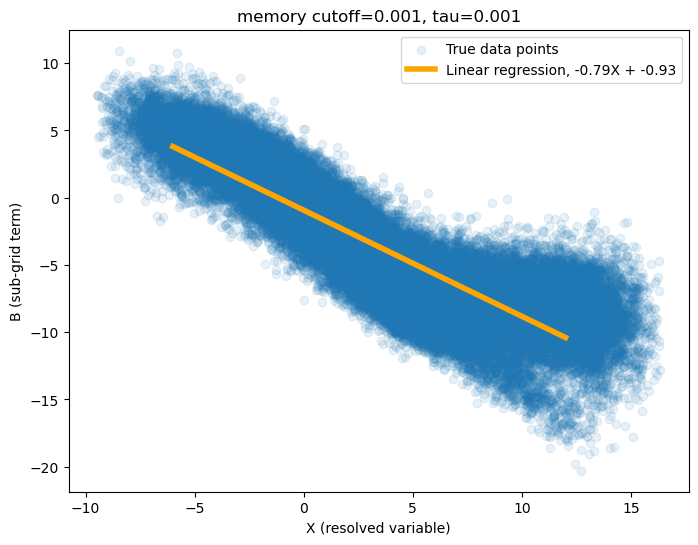

In [70]:
#plt.plot(X_train[:5000, 4].cpu().numpy())
#plt.scatter(X_train[:5000, 4].cpu().numpy(), B_train[:5000, 4].cpu().numpy())
linear_regression_fit(L96)

In [74]:
train_model(X_train[:, 7].reshape(-1, 1), X_test[:, 7].reshape(-1, 1), 
            B_train[:, 7].reshape(-1, 1), B_test[:, 7].reshape(-1, 1), 
            model, num_epochs=10000)

Training:   3%|▋                           | 253/10000 [00:01<01:03, 153.91it/s, Train Loss=3.3901, Test Loss=3.3752, R²=0.8377, Best R²=0.8377 @ 262]

Training: 100%|█████████████████████████| 10000/10000 [01:07<00:00, 148.83it/s, Train Loss=3.3820, Test Loss=3.3686, R²=0.8381, Best R²=0.8381 @ 8286]


FCNN(
  (linear1): Linear(in_features=1, out_features=16, bias=True)
  (linear2): Linear(in_features=16, out_features=16, bias=True)
  (linear3): Linear(in_features=16, out_features=16, bias=True)
  (linear4): Linear(in_features=16, out_features=16, bias=True)
  (linear5): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
)

In [13]:
model = NNpAE(past_timesteps, 8, 3)
train_model(Xks_lagged, Xks_test_lagged, Bks_lagged, Bks_test_lagged, model=model, num_epochs=5000);

Training:   0%|                                                                                                              | 0/5000 [00:00<?, ?it/s]

Training: 100%|████████████████████████████| 5000/5000 [08:34<00:00,  9.72it/s, Train Loss=1.1023, Test Loss=1.6495, R²=0.9242, Best R²=0.9312 @ 1096]


In [24]:
model = NNpAE(past_timesteps, 8, 3)
print(past_timesteps)
train_model(Xks_lagged, Xks_test_lagged, Bks_lagged, Bks_test_lagged, model=model, num_epochs=5000);

1


Training: 100%|████████████████████████████| 5000/5000 [01:14<00:00, 67.43it/s, Train Loss=1.3987, Test Loss=1.6952, R²=0.9224, Best R²=0.9242 @ 3778]


In [33]:
model = NNpAE(past_timesteps, 8, 3)
print(past_timesteps)
train_model(Xks_lagged, Xks_test_lagged, Bks_lagged, Bks_test_lagged, model=model, num_epochs=5000);

500


Training: 100%|████████████████████████████| 5000/5000 [05:12<00:00, 15.98it/s, Train Loss=1.1358, Test Loss=1.5721, R²=0.9279, Best R²=0.9317 @ 1163]
